In [1]:
import sys
sys.path.insert(0, '..')    # pour importer le code du dossier src/, situé un niveau au-dessus du notebook

import fastf1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.cleaning import select_long_run_laps
from src.data_loader import load_laps, load_track_temperature
from src.degradation import COMPOUNDS, fit_wear

fastf1.set_log_level('ERROR')    # masque les messages INFO / WARNING de FastF1

# Week-ends sur lesquels comparer l'usure mesurée en essais et l'usure mesurée en course.
# Week-ends classiques uniquement (trois séances d'essais), courses sèches et a priori sans Safety Car.
YEARS = [2023, 2024]
GRANDS_PRIX = ['Spain', 'Bahrain', 'Hungary', 'Monza']
PRACTICE_SESSIONS = ['FP1', 'FP2', 'FP3']
NEUTRALISATION_CODES = '[4567]'    # codes TrackStatus : Safety Car, drapeau rouge, VSC déployée, fin de VSC

# Téléchargement des tours et de la météo (le premier lancement télécharge, les suivants lisent le cache)
rows = []
for grand_prix in GRANDS_PRIX:
    for year in YEARS:
        row = {'Grand Prix': grand_prix, 'Année': year}
        try:
            row['Tours essais'] = sum(len(load_laps(year, grand_prix, name)) for name in PRACTICE_SESSIONS)
            race_laps = load_laps(year, grand_prix, 'R')
            row['Tours course'] = len(race_laps)
            row['Tours neutralisés'] = race_laps['TrackStatus'].astype(str).str.contains(NEUTRALISATION_CODES).sum()
            for name in PRACTICE_SESSIONS:
                row[f'Piste {name} (°C)'] = load_track_temperature(year, grand_prix, name)
            row['Piste course (°C)'] = load_track_temperature(year, grand_prix, 'R')
        except Exception as error:    # un week-end en échec n'empêche pas de charger les autres
            row['Erreur'] = f'{type(error).__name__} : {error}'
        rows.append(row)

weekends = pd.DataFrame(rows).set_index(['Grand Prix', 'Année'])
weekends.round(1)

Tours essais  Tours course  Tours neutralisés  \
Grand Prix Année                                                  
Spain      2023           1454          1312                  0   
           2024           1482          1310                  0   
Bahrain    2023           1246          1056                 32   
           2024           1271          1129                  0   
Hungary    2023           1163          1252                  0   
           2024           1296          1355                  0   
Monza      2023           1357           957                  0   
           2024           1269          1008                  0   

                  Piste FP1 (°C)  Piste FP2 (°C)  Piste FP3 (°C)  \
Grand Prix Année                                                   
Spain      2023             42.1            34.3            20.3   
           2024             47.1            43.1            43.4   
Bahrain    2023             40.5            27.0            40.6   
           2024             34.2            22.1            32.0   
Hungary    2023             29.5            32.9            45.8   
           2024             58.5            45.8            39.1   
Monza      2023             37.1            36.4            39.8   
           2024             50.8            44.4            46.3   

                  Piste course (°C)  
Grand Prix Année                     
Spain      2023                33.8  
           2024                41.1  
Bahrain    2023                31.0  
           2024                23.7  
Hungary    2023                48.6  
           2024                44.9  
Monza      2023                42.9  
           2024                49.3

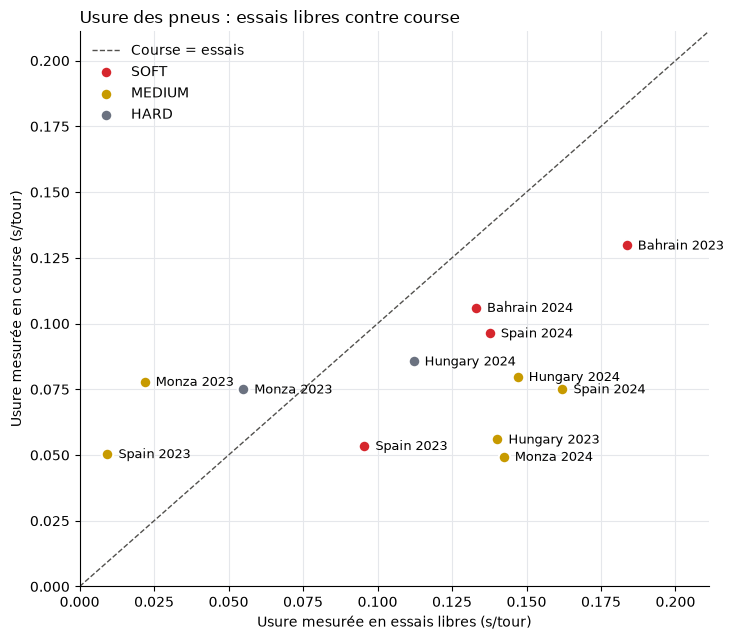

Usure essais (s/tour)  Relais essais  \
Grand Prix Année Composé                                         
Spain      2023  SOFT                     0.096             15   
                 MEDIUM                   0.009              9   
                 HARD                       NaN              0   
           2024  SOFT                     0.138             13   
                 MEDIUM                   0.162             15   
                 HARD                     0.170              3   
Bahrain    2023  SOFT                     0.184             22   
                 MEDIUM                   0.152              6   
                 HARD                     0.176              2   
           2024  SOFT                     0.133             21   
                 MEDIUM                   0.081              5   
                 HARD                       NaN              0   
Hungary    2023  SOFT                     0.155              1   
                 MEDIUM                   0.140             18   
                 HARD                     0.223              1   
           2024  SOFT                     0.193              8   
                 MEDIUM                   0.147             19   
                 HARD                     0.112              4   
Monza      2023  SOFT                     0.140              6   
                 MEDIUM                   0.022              9   
                 HARD                     0.055              6   
           2024  SOFT                     0.358              1   
                 MEDIUM                   0.142             16   
                 HARD                       NaN              0   

                          Usure course (s/tour)  Relais course  \
Grand Prix Année Composé                                         
Spain      2023  SOFT                     0.053             17   
                 MEDIUM                   0.050             17   
                 HARD                     0.062             22   
           2024  SOFT                     0.096             25   
                 MEDIUM                   0.075             19   
                 HARD                     0.067             13   
Bahrain    2023  SOFT                     0.130             24   
                 MEDIUM                   0.285              1   
                 HARD                     0.085             27   
           2024  SOFT                     0.106             13   
                 MEDIUM                     NaN              0   
                 HARD                     0.088             36   
Hungary    2023  SOFT                     0.048              1   
                 MEDIUM                   0.056             19   
                 HARD                     0.071             28   
           2024  SOFT                     0.144              1   
                 MEDIUM                   0.080             18   
                 HARD                     0.086             29   
Monza      2023  SOFT                       NaN              0   
                 MEDIUM                   0.078             16   
                 HARD                     0.075             16   
           2024  SOFT                       NaN              0   
                 MEDIUM                   0.049             13   
                 HARD                     0.040             29   

                          Piste essais − course (°C)  Course / essais  Fiable  
Grand Prix Année Composé                                                       
Spain      2023  SOFT                         -1.598            0.560    True  
                 MEDIUM                       -1.598            5.414    True  
                 HARD                         -1.598              NaN   False  
           2024  SOFT                          3.404            0.700    True  
                 MEDIUM                        3.404            0.463    True  
                 HARD           

In [2]:
# --- Usure mesurée en essais et usure mesurée en course, avec la même méthode ---
FUEL_EFFECT_PER_LAP = 0.05    # gain dû à l'allègement (s/tour), supposé identique en essais et en course
MIN_STINTS = 4                # nombre minimal de relais, en essais comme en course, pour juger la mesure fiable
COMPOUND_COLORS = {'SOFT': '#d6262d', 'MEDIUM': '#c79a00', 'HARD': '#6b7280'}    # couleurs usuelles Pirelli

rows = []
for (grand_prix, year), weekend in weekends.iterrows():
    if 'Erreur' in weekends.columns and pd.notna(weekend['Erreur']):
        continue    # week-end non chargé
    practice_laps = pd.concat([load_laps(year, grand_prix, name) for name in PRACTICE_SESSIONS], ignore_index=True)
    race_laps = load_laps(year, grand_prix, 'R')
    # Même tri et même ajustement des deux côtés : seuls les tours réguliers, hors trafic, des relais assez longs
    practice_wear, _ = fit_wear(select_long_run_laps(practice_laps), FUEL_EFFECT_PER_LAP)
    race_wear, _ = fit_wear(select_long_run_laps(race_laps), FUEL_EFFECT_PER_LAP)
    practice_temperature = weekend[[f'Piste {name} (°C)' for name in PRACTICE_SESSIONS]].mean()
    for compound in COMPOUNDS:
        rows.append({
            'Grand Prix': grand_prix,
            'Année': year,
            'Composé': compound,
            'Usure essais (s/tour)': practice_wear['Usure (s/tour)'].get(compound, np.nan),
            'Relais essais': practice_wear['Relais'].get(compound, 0),
            'Usure course (s/tour)': race_wear['Usure (s/tour)'].get(compound, np.nan),
            'Relais course': race_wear['Relais'].get(compound, 0),
            # Écart de température de piste : moyenne des essais moins course
            'Piste essais − course (°C)': practice_temperature - weekend['Piste course (°C)'],
        })

comparison = pd.DataFrame(rows).set_index(['Grand Prix', 'Année', 'Composé'])
comparison['Course / essais'] = comparison['Usure course (s/tour)'] / comparison['Usure essais (s/tour)']
comparison['Fiable'] = (comparison['Relais essais'] >= MIN_STINTS) & (comparison['Relais course'] >= MIN_STINTS)

# Un point par (Grand Prix, année, composé) mesuré de façon fiable des deux côtés
reliable = comparison[comparison['Fiable']]
fig, ax = plt.subplots(figsize=(7.5, 6.5))
axis_max = 1.15 * reliable['Usure essais (s/tour)'].max()
ax.plot([0, axis_max], [0, axis_max], color='#52514e', linewidth=1, linestyle='--', label='Course = essais')
for compound in COMPOUNDS:
    if compound in reliable.index.get_level_values('Composé'):
        points = reliable.xs(compound, level='Composé')
        ax.scatter(points['Usure essais (s/tour)'], points['Usure course (s/tour)'], s=70,
                   color=COMPOUND_COLORS[compound], edgecolor='white', linewidth=1.5, zorder=3, label=compound)
        for (grand_prix, year), point in points.iterrows():
            ax.annotate(f'{grand_prix} {year}', (point['Usure essais (s/tour)'], point['Usure course (s/tour)']),
                        xytext=(8, -3), textcoords='offset points', fontsize=9)
ax.set_xlim(0, axis_max)
ax.set_ylim(0, axis_max)
ax.set_xlabel('Usure mesurée en essais libres (s/tour)')
ax.set_ylabel('Usure mesurée en course (s/tour)')
ax.set_title('Usure des pneus : essais libres contre course', loc='left')
ax.grid(color='#e5e7eb', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, loc='upper left')
fig.tight_layout()
fig.savefig('../figures/practice_vs_race_wear.png', dpi=150, bbox_inches='tight')
plt.show()

comparison.round(3)

In [3]:
# --- Le rapport course / essais est-il propre au circuit ? ---
# Si oui, il doit être proche d'une année sur l'autre pour un même circuit et un même composé.
# On met les années côte à côte, pour les seules mesures fiables.
ratio_by_year = reliable['Course / essais'].unstack('Année')
wear_by_year = reliable['Usure course (s/tour)'].unstack('Année')

pd.concat({'Course / essais': ratio_by_year, 'Usure course (s/tour)': wear_by_year}, axis=1).round(2)

Course / essais       Usure course (s/tour)      
Année                         2023  2024                  2023  2024
Grand Prix Composé                                                  
Bahrain    SOFT               0.71  0.80                  0.13  0.11
Hungary    HARD                NaN  0.76                   NaN  0.09
           MEDIUM             0.40  0.54                  0.06  0.08
Monza      HARD               1.37   NaN                  0.07   NaN
           MEDIUM             3.57  0.35                  0.08  0.05
Spain      MEDIUM             5.41  0.46                  0.05  0.08
           SOFT               0.56  0.70                  0.05  0.10